# Fitting di dati con `scipy.optimize.curve_fit`


## 1. Cos'è un fit?

Abbiamo punti sperimentali $(x_i,y_i)$ e scegliamo un **modello** $f(x,\theta)$: una relazione matematica che potrebbe descriverli. I simboli in $\theta$ sono i **parametri del modello**; i numeri trovati usando i dati sono i loro **valori fitted** (o stimati).

Intuitivamente, `curve_fit` cerca i parametri che rendono piccola la somma dei quadrati degli scarti:

$$\sum_i \left[y_i-f(x_i,\theta)\right]^2.$$

I **dati** sono dunque le misure; il **modello** è la nostra ipotesi sulla loro forma. Un fit non dimostra che il modello sia vero: trova i suoi parametri migliori per quei dati.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

rng = np.random.default_rng(42)

La chiamata essenziale è:

```python
popt, pcov = curve_fit(model, x_data, y_data)
```

`popt` contiene i parametri ottimali, nello stesso ordine degli argomenti del modello dopo `x`. `pcov` è la matrice di covarianza stimata: qui ci serve solo la sua diagonale per ricavare le incertezze dei parametri.

## 2. Fit lineare senza barre d'errore

Partiamo da $y=mx+q$ e rendiamo esplicito ogni passaggio.

In [2]:
# 1. Generazione dei dati
x_linear = np.linspace(0, 8, 18)
y_linear = 2.0 * x_linear + 1.2 + rng.normal(0, 0.7, size=x_linear.size)

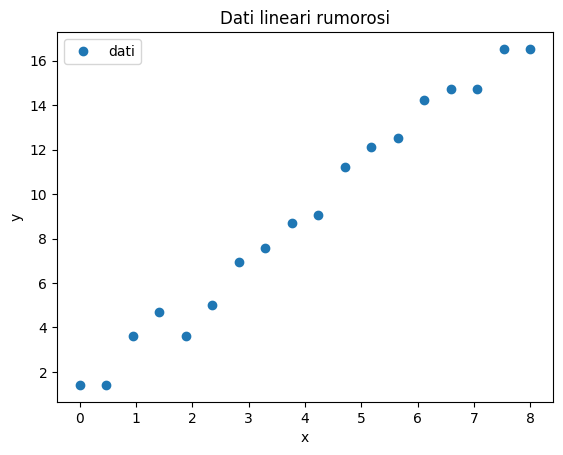

In [6]:
# 2. Primo sguardo ai dati
plt.plot(x_linear, y_linear,'o', label="dati")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dati lineari rumorosi")
plt.legend()
plt.show()

In [7]:
# 3. Modello: x deve essere il primo argomento
def linear_model(x, m, q):
    return m * x + q

In [8]:
# 4-5. Fit e parametri ottimali
popt_linear, pcov_linear = curve_fit(linear_model, x_linear, y_linear)
m_fit, q_fit = popt_linear
print(f"m = {m_fit:.3f}")
print(f"q = {q_fit:.3f}")

m = 2.026
q = 1.039


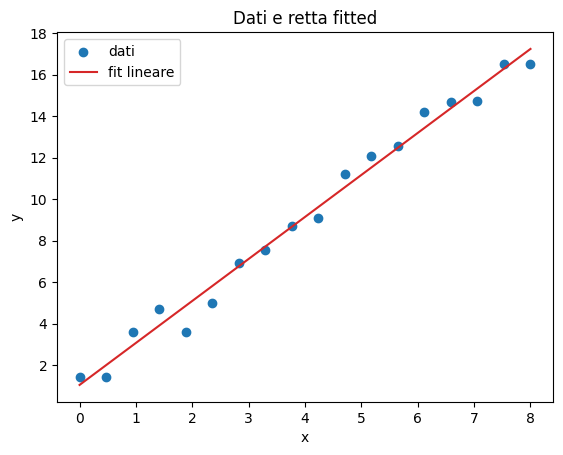

In [9]:
# 6-7. Una griglia fitta produce una retta liscia
x_fit_linear = np.linspace(x_linear.min(), x_linear.max(), 300)
y_fit_linear = linear_model(x_fit_linear, *popt_linear)

plt.scatter(x_linear, y_linear, label="dati") #dati
plt.plot(x_fit_linear, y_fit_linear, color="tab:red", label="fit lineare") #modello
plt.xlabel("x")
plt.ylabel("y")
plt.title("Dati e retta fitted")
plt.legend()
plt.show()

In [7]:
# 8-9. Incertezze: radice quadrata della diagonale di pcov
perr_linear = np.sqrt(np.diag(pcov_linear))
print(f"m = {popt_linear[0]:.2f} ± {perr_linear[0]:.2f}")
print(f"q = {popt_linear[1]:.2f} ± {perr_linear[1]:.2f}")

m = 2.03 ± 0.06
q = 1.04 ± 0.29


## 3. Fit esponenziale senza barre d'errore

Ora usiamo $y=Ae^{-x/\tau}$. Il workflow non cambia, ma il modello è non lineare nei parametri.

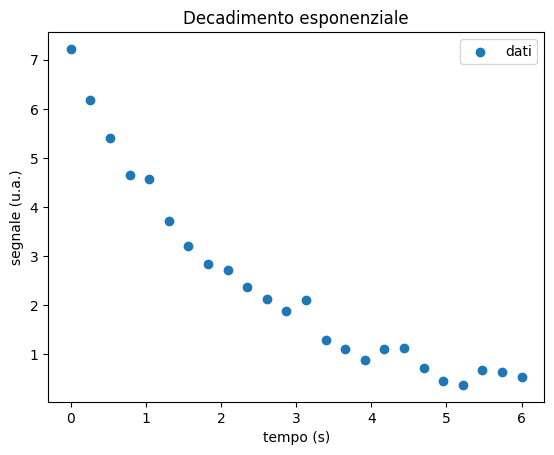

In [10]:
# Dati → grafico
x_exp = np.linspace(0, 6, 24)
y_exp = 7.0 * np.exp(-x_exp / 2.1) + rng.normal(0, 0.25, size=x_exp.size)

plt.scatter(x_exp, y_exp, label="dati")
plt.xlabel("tempo (s)")
plt.ylabel("segnale (u.a.)")
plt.title("Decadimento esponenziale")
plt.legend()
plt.show()

In [11]:
# Modello → curve_fit → parametri → incertezze
def exponential_model(x, A, tau):
    return A * np.exp(-x / tau)

p0_exp = [6.0, 2.0]
popt_exp, pcov_exp = curve_fit(exponential_model, x_exp, y_exp, p0=p0_exp)
perr_exp = np.sqrt(np.diag(pcov_exp))
print(f"A   = {popt_exp[0]:.2f} ± {perr_exp[0]:.2f}")
print(f"tau = {popt_exp[1]:.2f} ± {perr_exp[1]:.2f} s")

A   = 7.03 ± 0.12
tau = 2.13 ± 0.06 s


`p0` contiene valori iniziali sensati da cui far partire la ricerca. Nei fit non lineari può facilitare la convergenza, ma **non** è il risultato finale: il risultato è `popt`.

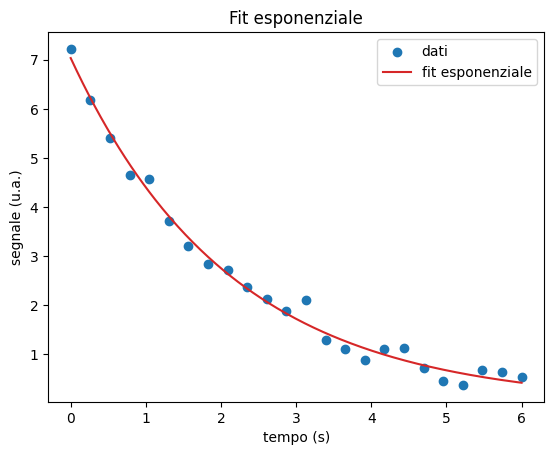

In [12]:
# Curva fitted
x_fit_exp = np.linspace(x_exp.min(), x_exp.max(), 300)
plt.scatter(x_exp, y_exp, label="dati")
plt.plot(x_fit_exp, exponential_model(x_fit_exp, *popt_exp),
         color="tab:red", label="fit esponenziale")
plt.xlabel("tempo (s)")
plt.ylabel("segnale (u.a.)")
plt.title("Fit esponenziale")
plt.legend()
plt.show()

## 4. Fit gaussiano senza barre d'errore

Usiamo
$$f(x)=A\exp\left[-\frac{(x-\mu)^2}{2\sigma^2}\right].$$

`A` è l'altezza del picco, `mu` la posizione del centro e `sigma` ne descrive la larghezza.

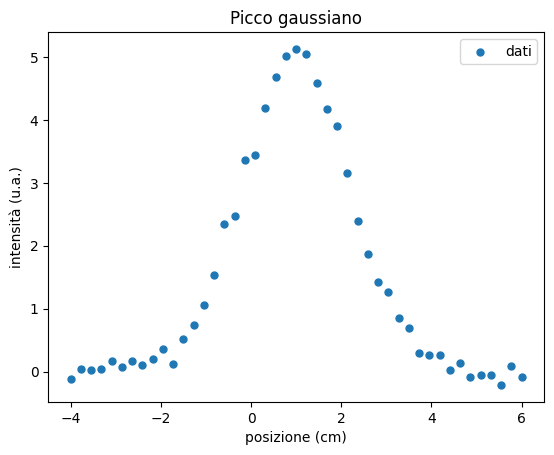

In [13]:
# Dati → grafico
x_gauss = np.linspace(-4, 6, 45)
y_gauss = 5.0 * np.exp(-(x_gauss - 1.0)**2 / (2 * 1.2**2))
y_gauss += rng.normal(0, 0.18, size=x_gauss.size)

plt.scatter(x_gauss, y_gauss, s=25, label="dati")
plt.xlabel("posizione (cm)")
plt.ylabel("intensità (u.a.)")
plt.title("Picco gaussiano")
plt.legend()
plt.show()

A     = 5.04 ± 0.05
mu    = 1.00 ± 0.01
sigma = 1.18 ± 0.01


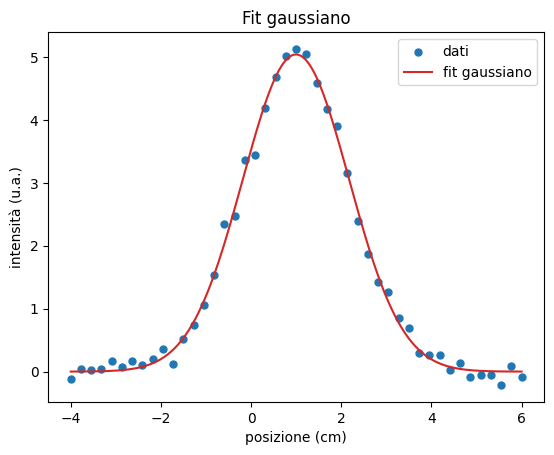

In [14]:
# Modello → curve_fit → parametri → incertezze → curva fitted
def gaussian_model(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

popt_gauss, pcov_gauss = curve_fit(
    gaussian_model, x_gauss, y_gauss, p0=[4.5, 1.0, 1.0]
)
perr_gauss = np.sqrt(np.diag(pcov_gauss))
for name, value, error in zip(["A", "mu", "sigma"], popt_gauss, perr_gauss):
    print(f"{name:5s} = {value:.2f} ± {error:.2f}")

x_fit_gauss = np.linspace(x_gauss.min(), x_gauss.max(), 400)
plt.scatter(x_gauss, y_gauss, s=25, label="dati")
plt.plot(x_fit_gauss, gaussian_model(x_fit_gauss, *popt_gauss),
         color="tab:red", label="fit gaussiano")
plt.xlabel("posizione (cm)")
plt.ylabel("intensità (u.a.)")
plt.title("Fit gaussiano")
plt.legend()
plt.show()

Poiché la funzione è definita come `gaussian_model(x, A, mu, sigma)`, `popt[0]`, `popt[1]` e `popt[2]` corrispondono rispettivamente ad `A`, `mu` e `sigma`.

## 5. Come generalizzare a qualunque funzione

```python
def model(x, p1, p2, p3):
    return ...

popt, pcov = curve_fit(model, x_data, y_data)
```

Possiamo fittare praticamente qualsiasi modello parametrico se sappiamo scriverlo come funzione Python, i parametri da stimare sono argomenti dopo `x` e il problema è sufficientemente ben posto. Per modelli non lineari possono servire valori iniziali `p0` sensati. Poi si applicano sempre gli stessi passaggi già visti.

## 6. Analisi dei residui

I residui sono
$$r_i=y_i-f(x_i,\theta_{\mathrm{fit}}).$$

Residui dispersi casualmente intorno a zero sono compatibili con un modello ragionevole. Un pattern sistematico suggerisce invece che il modello non descriva qualche struttura presente nei dati.

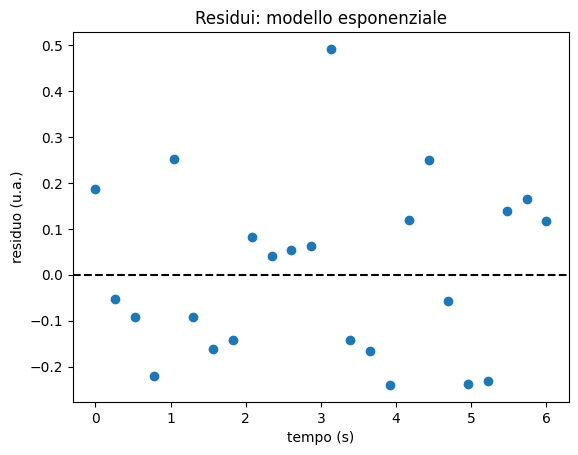

In [15]:
# Residui del fit esponenziale corretto
y_pred_exp = exponential_model(x_exp, *popt_exp)
residuals_exp = y_exp - y_pred_exp

plt.scatter(x_exp, residuals_exp)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("tempo (s)")
plt.ylabel("residuo (u.a.)")
plt.title("Residui: modello esponenziale")
plt.show()

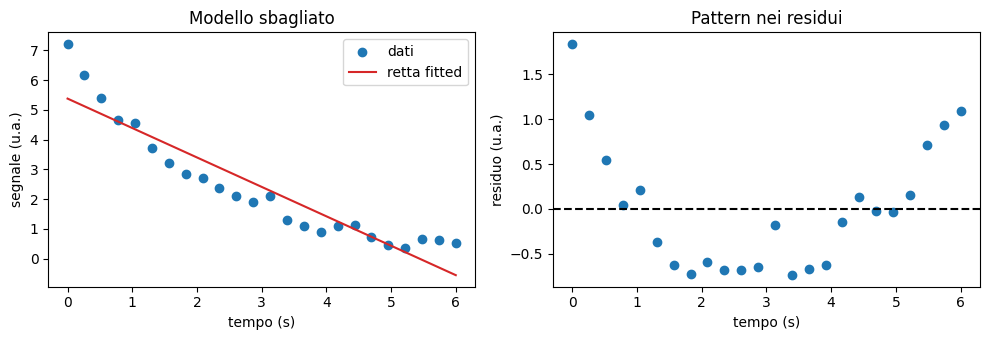

In [14]:
# Modello volutamente sbagliato: una retta sui dati esponenziali
popt_wrong, _ = curve_fit(linear_model, x_exp, y_exp)
residuals_wrong = y_exp - linear_model(x_exp, *popt_wrong)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].scatter(x_exp, y_exp, label="dati")
axes[0].plot(x_fit_exp, linear_model(x_fit_exp, *popt_wrong),
             color="tab:red", label="retta fitted")
axes[0].set(xlabel="tempo (s)", ylabel="segnale (u.a.)", title="Modello sbagliato")
axes[0].legend()
axes[1].scatter(x_exp, residuals_wrong)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set(xlabel="tempo (s)", ylabel="residuo (u.a.)", title="Pattern nei residui")
plt.tight_layout()
plt.show()

## 7. Dati con barre d'errore

https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html

Se ogni misura $y_i$ ha un'incertezza nota `sigma_y`, la mostriamo con `plt.errorbar(..., yerr=sigma_y, fmt="o", capsize=3)`. Nel fit pesato usiamo:

```python
popt, pcov = curve_fit(
    model, x_data, y_data,
    sigma=sigma_y, absolute_sigma=True
)
```

I punti con errore piccolo pesano di più, quelli con errore grande meno. Con `absolute_sigma=True`, SciPy interpreta `sigma_y` come incertezze assolute delle misure.

## 8. Tre fit con errori

Ripetiamo lo stesso workflow. Le incertezze variano da punto a punto.

### 8.1 Fit lineare con errorbar

m = 1.53 ± 0.03
q = -0.66 ± 0.12


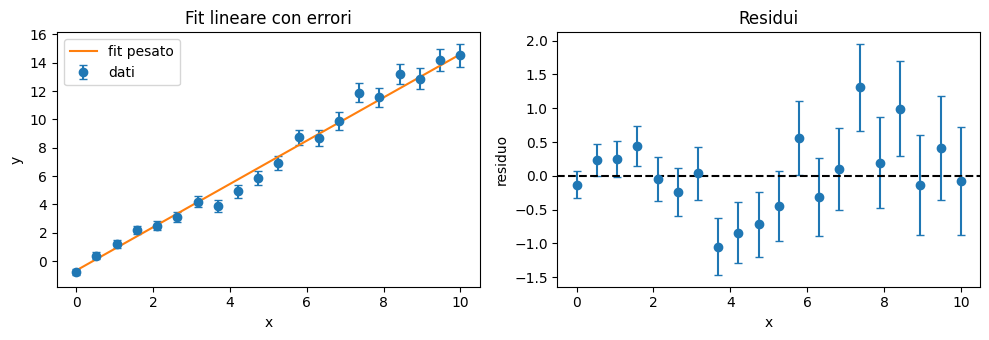

In [16]:
x_lw = np.linspace(0, 10, 20)
sigma_lw = 0.20 + 0.06 * x_lw
y_lw = 1.6 * x_lw - 0.8 + rng.normal(0, 0.7,size=x_lw.size)
popt_lw, pcov_lw = curve_fit(linear_model, x_lw, y_lw,
                             sigma=sigma_lw, absolute_sigma=True)
perr_lw = np.sqrt(np.diag(pcov_lw))
print(f"m = {popt_lw[0]:.2f} ± {perr_lw[0]:.2f}")
print(f"q = {popt_lw[1]:.2f} ± {perr_lw[1]:.2f}")

x_grid = np.linspace(x_lw.min(), x_lw.max(), 300)
residuals_lw = y_lw - linear_model(x_lw, *popt_lw)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].errorbar(x_lw, y_lw, yerr=sigma_lw, fmt="o", capsize=3, label="dati") #dati lineari con errori
axes[0].plot(x_grid, linear_model(x_grid, *popt_lw), label="fit pesato")  #fit
axes[0].set(xlabel="x", ylabel="y", title="Fit lineare con errori") 
axes[0].legend()
axes[1].errorbar(x_lw, residuals_lw, yerr=sigma_lw, fmt="o", capsize=3) #residui
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set(xlabel="x", ylabel="residuo", title="Residui")
plt.tight_layout(); plt.show()

### 8.2 Fit esponenziale con errorbar

A = 5.96 ± 0.09
tau = 2.50 ± 0.08 s


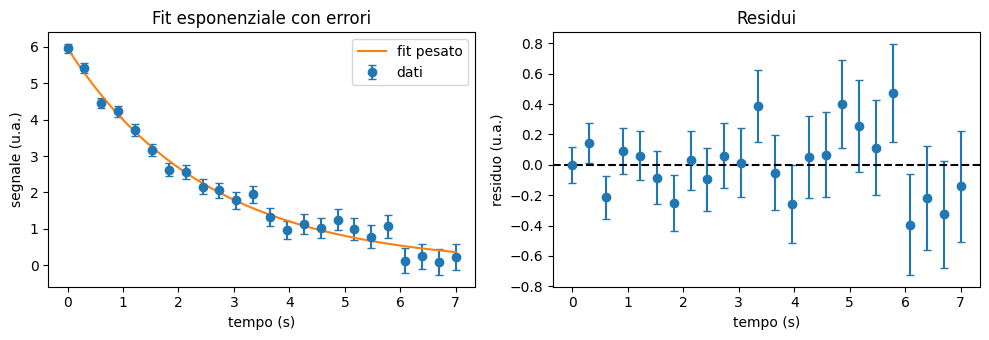

In [17]:
x_ew = np.linspace(0, 7, 24)
sigma_ew = 0.12 + 0.035 * x_ew
y_ew = 6.0 * np.exp(-x_ew / 2.5) + rng.normal(0, sigma_ew)
popt_ew, pcov_ew = curve_fit(exponential_model, x_ew, y_ew, p0=[5.5, 2.0],
                             sigma=sigma_ew, absolute_sigma=True)
perr_ew = np.sqrt(np.diag(pcov_ew))
print(f"A = {popt_ew[0]:.2f} ± {perr_ew[0]:.2f}")
print(f"tau = {popt_ew[1]:.2f} ± {perr_ew[1]:.2f} s")

x_grid = np.linspace(x_ew.min(), x_ew.max(), 300)
residuals_ew = y_ew - exponential_model(x_ew, *popt_ew)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].errorbar(x_ew, y_ew, yerr=sigma_ew, fmt="o", capsize=3, label="dati")
axes[0].plot(x_grid, exponential_model(x_grid, *popt_ew), label="fit pesato")
axes[0].set(xlabel="tempo (s)", ylabel="segnale (u.a.)", title="Fit esponenziale con errori")
axes[0].legend()
axes[1].errorbar(x_ew, residuals_ew, yerr=sigma_ew, fmt="o", capsize=3)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set(xlabel="tempo (s)", ylabel="residuo (u.a.)", title="Residui")
plt.tight_layout(); plt.show()

### 8.3 Fit gaussiano con errorbar

A     = 4.17 ± 0.05
mu    = 0.70 ± 0.02
sigma = 1.10 ± 0.02


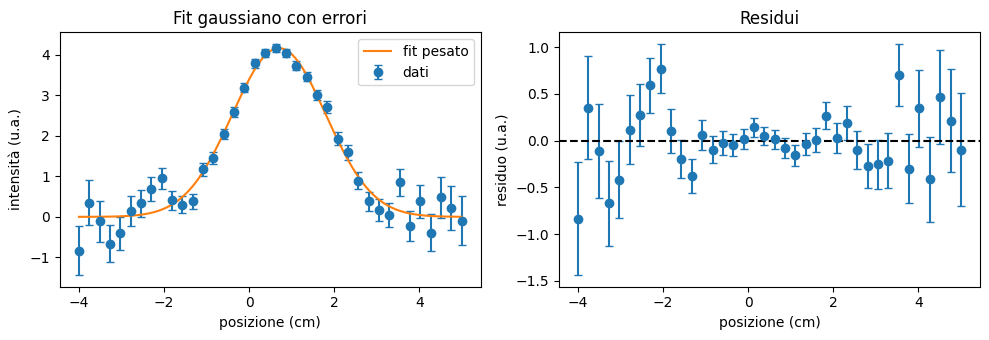

In [18]:
x_gw = np.linspace(-4, 5, 38)
sigma_gw = 0.10 + 0.025 * (x_gw - 0.5)**2
y_gw = gaussian_model(x_gw, 4.2, 0.7, 1.1) + rng.normal(0, sigma_gw)
popt_gw, pcov_gw = curve_fit(gaussian_model, x_gw, y_gw, p0=[4.0, 0.5, 1.0],
                             sigma=sigma_gw, absolute_sigma=True)
perr_gw = np.sqrt(np.diag(pcov_gw))
for name, value, error in zip(["A", "mu", "sigma"], popt_gw, perr_gw):
    print(f"{name:5s} = {value:.2f} ± {error:.2f}")

x_grid = np.linspace(x_gw.min(), x_gw.max(), 400)
residuals_gw = y_gw - gaussian_model(x_gw, *popt_gw)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].errorbar(x_gw, y_gw, yerr=sigma_gw, fmt="o", capsize=3, label="dati")
axes[0].plot(x_grid, gaussian_model(x_grid, *popt_gw), label="fit pesato")
axes[0].set(xlabel="posizione (cm)", ylabel="intensità (u.a.)", title="Fit gaussiano con errori")
axes[0].legend()
axes[1].errorbar(x_gw, residuals_gw, yerr=sigma_gw, fmt="o", capsize=3)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set(xlabel="posizione (cm)", ylabel="residuo (u.a.)", title="Residui")
plt.tight_layout(); plt.show()

## 9. Fit 2D: un piano

Ora ogni misura ha coordinate $(x,y,z)$ e il modello è $z=f(x,y;\theta)$. Usiamo il piano
$$z=ax+by+c.$$

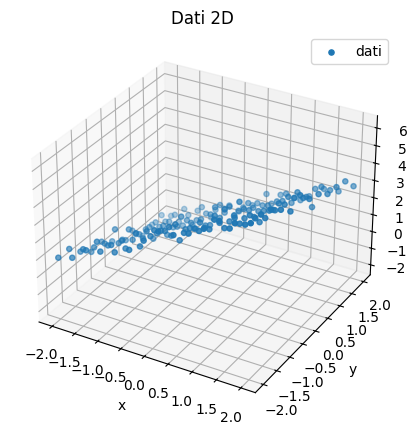

In [19]:
# Punti (x, y, z) su una griglia, con rumore
x_axis = np.linspace(-2, 2, 14)
y_axis = np.linspace(-2, 2, 12)
x_mesh, y_mesh = np.meshgrid(x_axis, y_axis)
z_data = 1.3 * x_mesh - 0.8 * y_mesh + 2.0
z_data += rng.normal(0, 0.25, size=z_data.shape)

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(projection="3d")
ax.scatter(x_mesh, y_mesh, z_data, s=14, label="dati")
ax.set(xlabel="x", ylabel="y", zlabel="z", title="Dati 2D")
ax.legend()
plt.show()

In [20]:
# curve_fit riceve insieme le due coordinate indipendenti.
# Sia le coordinate sia z vengono appiattite in vettori 1D corrispondenti.
def plane_model(xy, a, b, c):
    x, y = xy
    return a * x + b * y + c

xy_flat = (x_mesh.ravel(), y_mesh.ravel())
z_flat = z_data.ravel()
popt_plane, pcov_plane = curve_fit(plane_model, xy_flat, z_flat)
perr_plane = np.sqrt(np.diag(pcov_plane))
for name, value, error in zip(["a", "b", "c"], popt_plane, perr_plane):
    print(f"{name} = {value:.2f} ± {error:.2f}")

a = 1.29 ± 0.02
b = -0.79 ± 0.02
c = 2.01 ± 0.02


`curve_fit` confronta vettori di osservazioni. `ravel()` trasforma quindi ogni griglia 2D in un vettore 1D senza cambiare la corrispondenza tra le coordinate e il valore di $z$. Per disegnare il risultato riportiamo poi le predizioni alla forma della griglia con `reshape`.

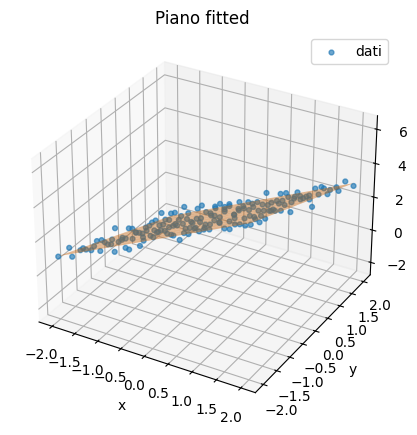

In [21]:
z_fit_flat = plane_model(xy_flat, *popt_plane)
z_fit_mesh = z_fit_flat.reshape(z_data.shape)

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(projection="3d")
ax.scatter(x_mesh, y_mesh, z_data, s=12, alpha=0.65, label="dati")
ax.plot_surface(x_mesh, y_mesh, z_fit_mesh, alpha=0.45, color="tab:orange")
ax.set(xlabel="x", ylabel="y", zlabel="z", title="Piano fitted")
ax.legend()
plt.show()

## 10. Esercizio finale: traiettoria con accelerazione costante

La posizione di un corpo misurata a tempi diversi può seguire
$$s(t)=a t^2+b t+c.$$

Il dataset e il primo grafico sono pronti. Completa le celle successive applicando l'intero workflow. Le barre rappresentano le incertezze sperimentali sulla posizione: usa quindi un fit pesato.

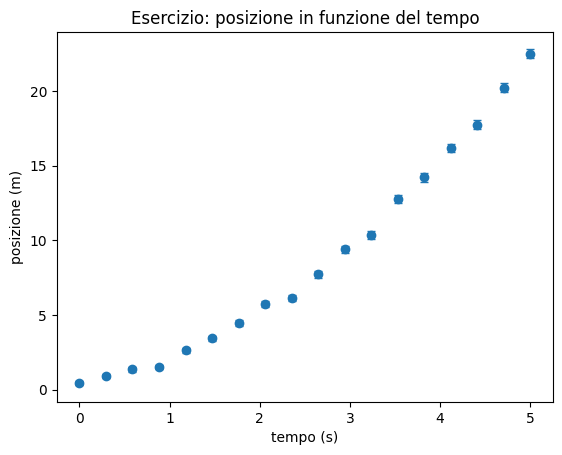

In [21]:
t_exercise = np.linspace(0, 5, 18)
sigma_s = 0.12 + 0.04 * t_exercise
s_exercise = 0.65 * t_exercise**2 + 1.1 * t_exercise + 0.4
s_exercise += rng.normal(0, sigma_s)

plt.errorbar(t_exercise, s_exercise, yerr=sigma_s, fmt="o", capsize=3)
plt.xlabel("tempo (s)")
plt.ylabel("posizione (m)")
plt.title("Esercizio: posizione in funzione del tempo")
plt.show()

In [22]:
# TODO: definisci il modello

# def quadratic_model(t, a, b, c):
#     return ...

In [23]:
# TODO: esegui il fit pesato

# popt_exercise, pcov_exercise = curve_fit(...)

In [24]:
# TODO: stampa i parametri con le incertezze

# perr_exercise = ...

In [25]:
# TODO: disegna dati e curva fitted

In [26]:
# TODO: calcola e visualizza i residui

### Checklist finale

1. Ho guardato i dati prima di scegliere il modello?  
2. Gli argomenti del modello e `popt` sono nello stesso ordine?  
3. Ho usato una griglia fitta solo per disegnare la curva?  
4. Ho ricavato le incertezze con `np.sqrt(np.diag(pcov))`?  
5. Ho controllato visivamente i residui?